In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.optimize as spyo
import matplotlib.pyplot as plt

SP500_URL = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
sp500_table = pd.read_html(
    SP500_URL, storage_options={'User-Agent': 'Mozzilla/5.0'}
)[0]
companies = sp500_table['Symbol'].str.replace('.', '-').tolist()
realisation_matrix = yf.download(companies, start='2021-08-24',end='2026-08-24')['Close']

[*********************100%***********************]  503 of 503 completed


In [18]:
realisation_matrix.head(5)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-08-24,164.622421,145.935013,99.614479,161.419998,113.870193,39.975777,304.614746,657.239990,152.380997,51.751831,...,28.282173,95.956604,58.221420,46.459621,126.125633,270.170013,121.592758,138.290955,578.710022,193.789459
2021-08-25,167.257202,144.706070,100.213768,160.350006,113.180626,40.013813,306.943726,656.799988,150.681229,52.350876,...,28.606695,97.307571,58.238468,46.543533,127.465347,267.570007,122.412308,139.825104,584.109985,193.260040
2021-08-26,167.537094,143.906235,100.213768,152.729996,113.842987,39.357689,306.750427,652.390015,154.418076,51.864708,...,28.558020,96.091705,58.229942,45.914116,126.691689,262.130005,120.090889,139.081284,578.909973,192.872467
2021-08-27,167.749390,144.940170,99.531250,154.179993,113.044510,39.700012,308.987305,658.520020,153.606110,52.585274,...,29.166502,97.510216,58.570961,46.803699,127.314392,268.010010,120.365074,139.527542,587.960022,192.683380
2021-08-30,170.567596,149.348816,100.355255,156.020004,114.269417,39.224564,310.220886,665.989990,154.067474,52.151199,...,29.426115,96.390839,58.852306,46.291767,128.767380,271.920013,119.442001,139.257919,584.780029,194.640244


In [19]:
# Denoising Matrix

# Drop tickers missing more than 5% of trading days
threshold = len(realisation_matrix) * 0.95
clean_prices = realisation_matrix.dropna(thresh=threshold, axis=1)

# Forward-fill and backward-fill tiny remaining gaps
clean_prices = clean_prices.ffill().bfill()

# Log taken for time additivity and symmetry. Making returns behave more
# like the normal distribution.
returns = np.log(clean_prices / clean_prices.shift(1)).dropna()

# Splitting data in order to train and test model.
split = int(len(returns) * 0.8)
returns_train = returns.iloc[:split]
returns_test = returns.iloc[split:]

# Standardising data as required for RMT.
standardized_returns_train = (
    (returns_train - returns_train.mean()) / returns_train.std()
)
x = standardized_returns_train.to_numpy()
n_obs, n_assets = x.shape

# Empirical Correlation Matrix
corr_empirical = 1 / n_obs * np.dot(x.T, x)
eigenvalues, eigenvectors = np.linalg.eigh(corr_empirical)

# Marchenko-Pastur Bound (upper)
lambda_plus = (1 + np.sqrt(n_assets / n_obs)) ** 2

# Treating eigenvalues lying in MP bounds as noise, and replacing such
# values by their mean.
signal = eigenvalues > lambda_plus
mean_noise = np.mean(eigenvalues[~signal])
eigenvalues_clean = eigenvalues.copy()
eigenvalues_clean[~signal] = mean_noise

# Reconstructing denoised matrix using eigenvalue decompostion, and
# renormalising
corr_clean = eigenvectors @ np.diag(eigenvalues_clean) @ eigenvectors.T
variances = np.diag(corr_clean)
corr_clean = (
    np.outer(1 / np.sqrt(variances), 1 / np.sqrt(variances)) * corr_clean
)

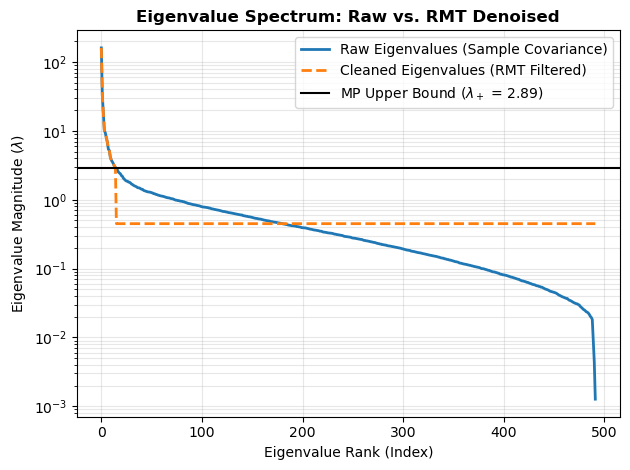

In [20]:
idx = np.argsort(eigenvalues)[::-1]
evals_raw_sorted = eigenvalues[idx]
evals_clean_sorted = eigenvalues_clean[idx]
plt.plot(
    evals_raw_sorted,
    label='Raw Eigenvalues (Sample Covariance)',
    linewidth=2,
)
plt.plot(
    evals_clean_sorted,
    label='Cleaned Eigenvalues (RMT Filtered)',
    linestyle='--',
    linewidth=2,
)
plt.axhline(
    y=lambda_plus,
    color='black',
    linewidth=1.5,
    label=rf'MP Upper Bound ($\lambda_+$ = {lambda_plus:.2f})',
)
plt.title(
    'Eigenvalue Spectrum: Raw vs. RMT Denoised',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Eigenvalue Rank (Index)', fontsize=10)
plt.ylabel(r'Eigenvalue Magnitude ($\lambda$)', fontsize=10)
plt.yscale('log')
plt.legend(loc='upper right')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Optimising portfolios (w) using the Sharpe Ratio for both Clean and
# Raw Covariance Matrices


# Sharpe Ratio as function of w
def sharpe_ratio(w, mu, sigma, rf=0.04):
    numerator = np.dot(w, mu) - rf  # Returns
    denominator = np.sqrt(np.dot(w, np.dot(sigma, w)))  # Risk
    sharpe = numerator / denominator
    # Negative to convert maximisation to minimisation for
    # scipy.optimize.minimize
    return -sharpe


# Annual daily asset standard deviation and annual mean returns, scaled
# accordingly with time and returns unlogged
train_returns_unlogged = np.expm1(returns_train.to_numpy())
sd_yearly = train_returns_unlogged.std(axis=0, ddof=1) * np.sqrt(252)
mu_yearly = train_returns_unlogged.mean(axis=0) * 252

# Converting correlation matrices to covariance matrices
sigma_clean = np.diag(sd_yearly) @ corr_clean @ np.diag(sd_yearly)
sigma_raw = np.diag(sd_yearly) @ corr_empirical @ np.diag(sd_yearly)

# Initial guess (can be optimised)
initial = np.ones(n_assets) / n_assets

# Bounds and constraints placed upon portfolio (w)
bounds = [(0, 1) for _ in range(n_assets)]
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

# Minimising Sharpe Ratio with corresponding clean and raw data
optimise_clean = spyo.minimize(
    fun=sharpe_ratio,
    x0=initial,
    args=(mu_yearly, sigma_clean),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
)
optimise_raw = spyo.minimize(
    fun=sharpe_ratio,
    x0=initial,
    args=(mu_yearly, sigma_raw),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
)
w_clean = optimise_clean.x
w_raw = optimise_raw.x

# Computing Sharpe Ratio on out of sample data, returns are unlogged
test_returns_unlogged = np.expm1(returns_test.to_numpy())
daily_ret_clean = test_returns_unlogged @ w_clean
daily_ret_raw = test_returns_unlogged @ w_raw
rf_daily = 0.04 / 252  # Annual risk free rate to daily
sharpe_out_clean = (
    (np.mean(daily_ret_clean) - rf_daily)
    / np.std(daily_ret_clean)
    * np.sqrt(252)
)
sharpe_out_raw = (
    (np.mean(daily_ret_raw) - rf_daily)
    / np.std(daily_ret_raw)
    * np.sqrt(252)
)

In [22]:
total_growth_clean = np.prod(1 + daily_ret_clean) - 1
total_growth_raw = np.prod(1 + daily_ret_raw) - 1
growth_improvement = (
    (total_growth_clean - total_growth_raw) / abs(total_growth_raw)
) * 100
print(f'Clean Portfolio Cumulative Return: {total_growth_clean * 100:.2f}%')
print(f'Raw Portfolio Cumulative Return: {total_growth_raw * 100:.2f}%')
print(f'Growth Improvement: {growth_improvement:.2f}%')

Clean Portfolio Cumulative Return: 26.83%
Raw Portfolio Cumulative Return: 21.01%
Growth Improvement: 27.70%


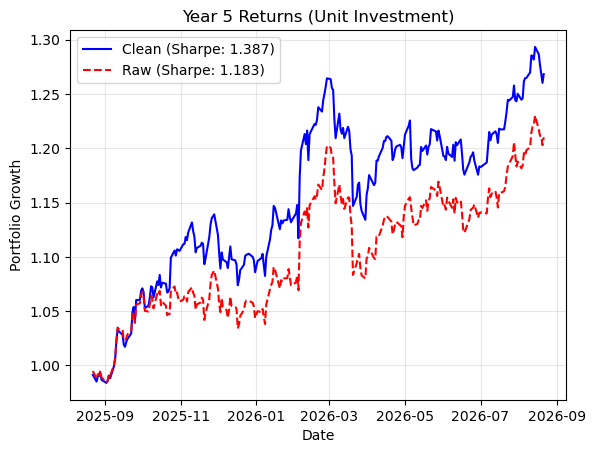

In [23]:
growth_clean = (1 + daily_ret_clean).cumprod()
growth_raw = (1 + daily_ret_raw).cumprod()
plt.plot(
    returns_test.index,
    growth_clean,
    label=f'Clean (Sharpe: {sharpe_out_clean:.3f})',
    color='blue',
)
plt.plot(
    returns_test.index,
    growth_raw,
    label=f'Raw (Sharpe: {sharpe_out_raw:.3f})',
    color='red',
    linestyle='--',
)
plt.title('Year 5 Returns (Unit Investment)')
plt.xlabel('Date')
plt.ylabel('Portfolio Growth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()